<a href="https://colab.research.google.com/github/Aswini-Raj/ML_Algorithms/blob/main/Insurance_claims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning Technique/insurance_claims.csv')
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


In [ ]:
df.shape

(1000, 40)

In [ ]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


<Axes: >

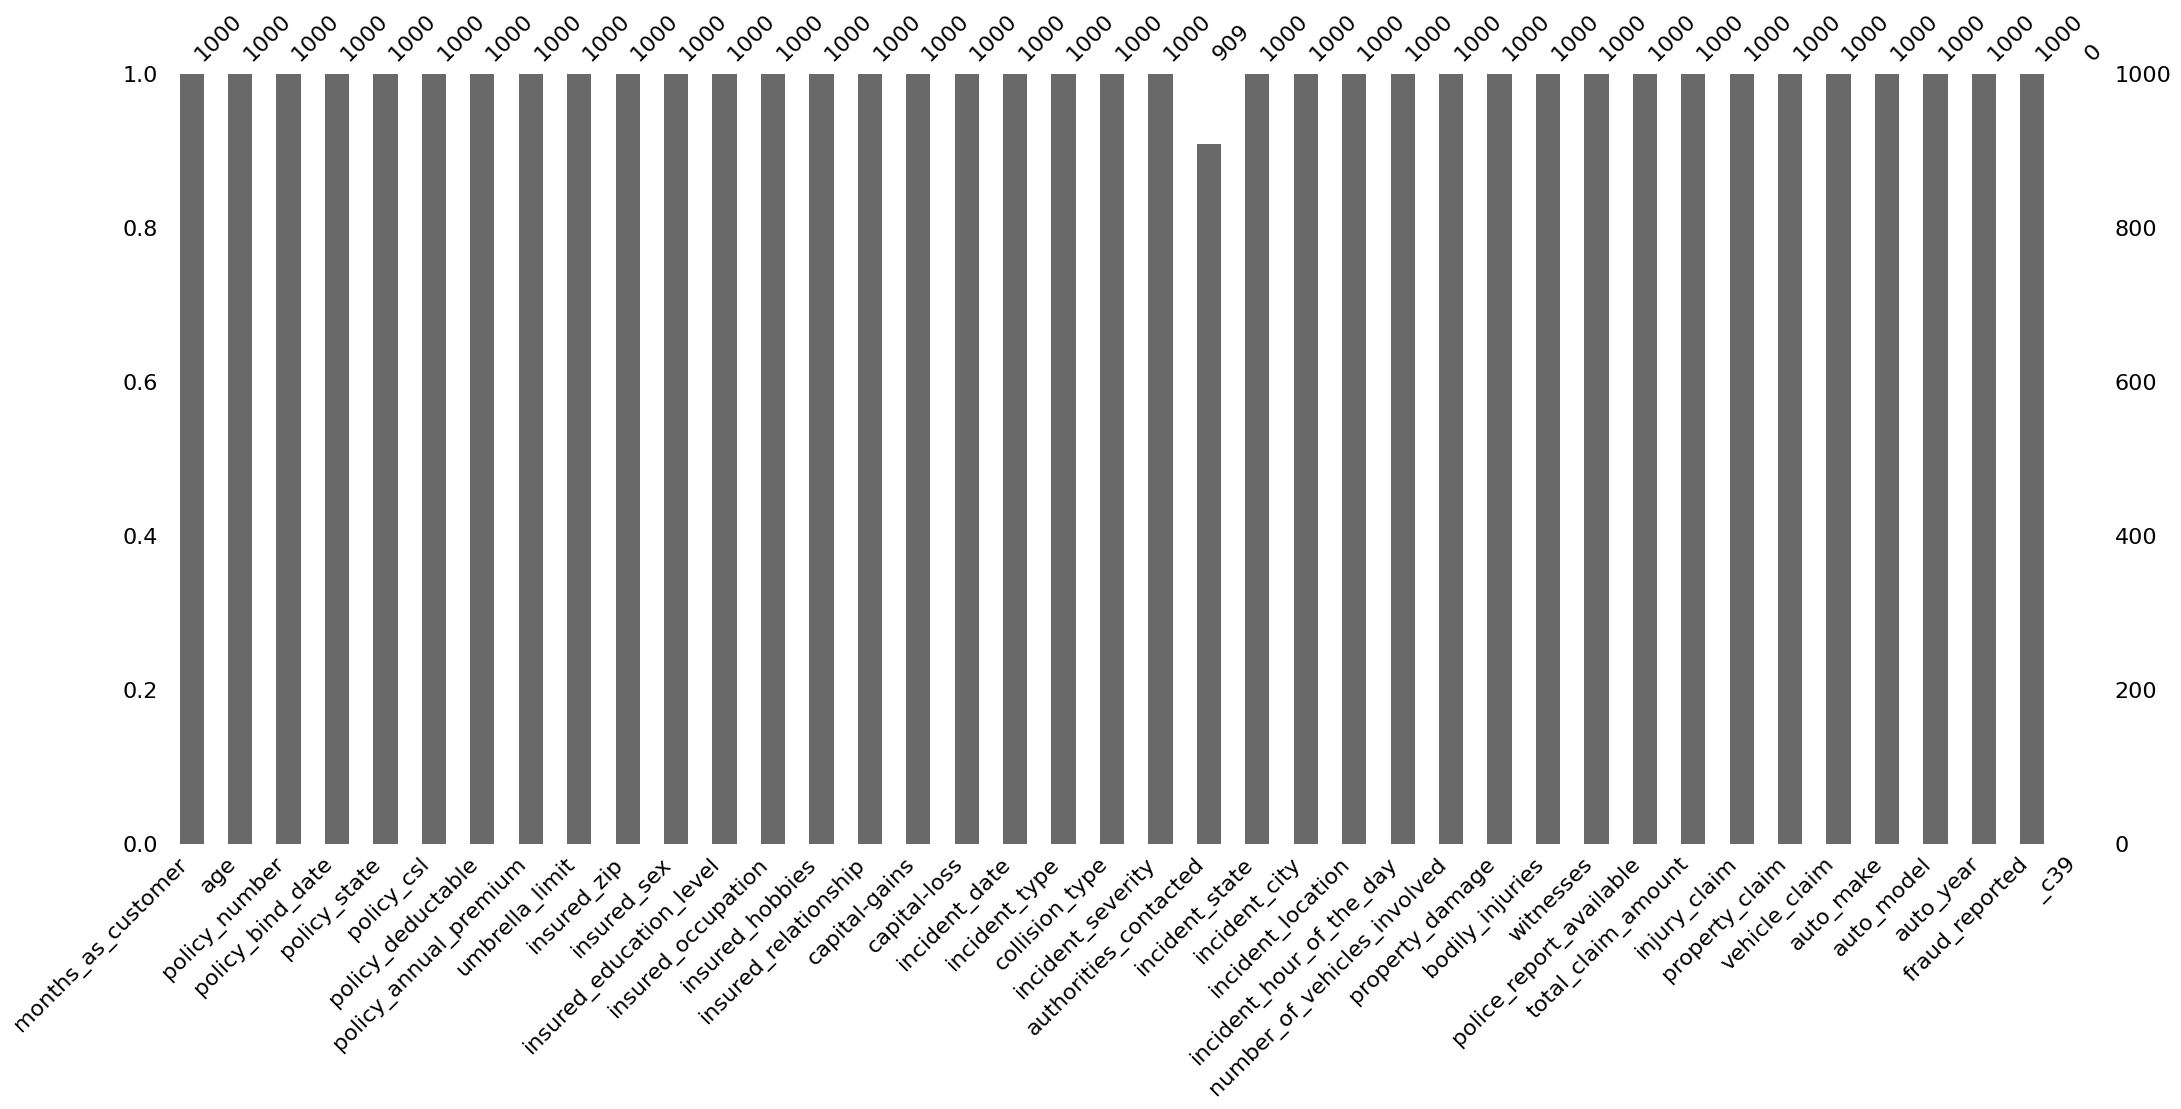

In [ ]:
!pip install missingno
import missingno as msno
msno.bar(df)

<Axes: >

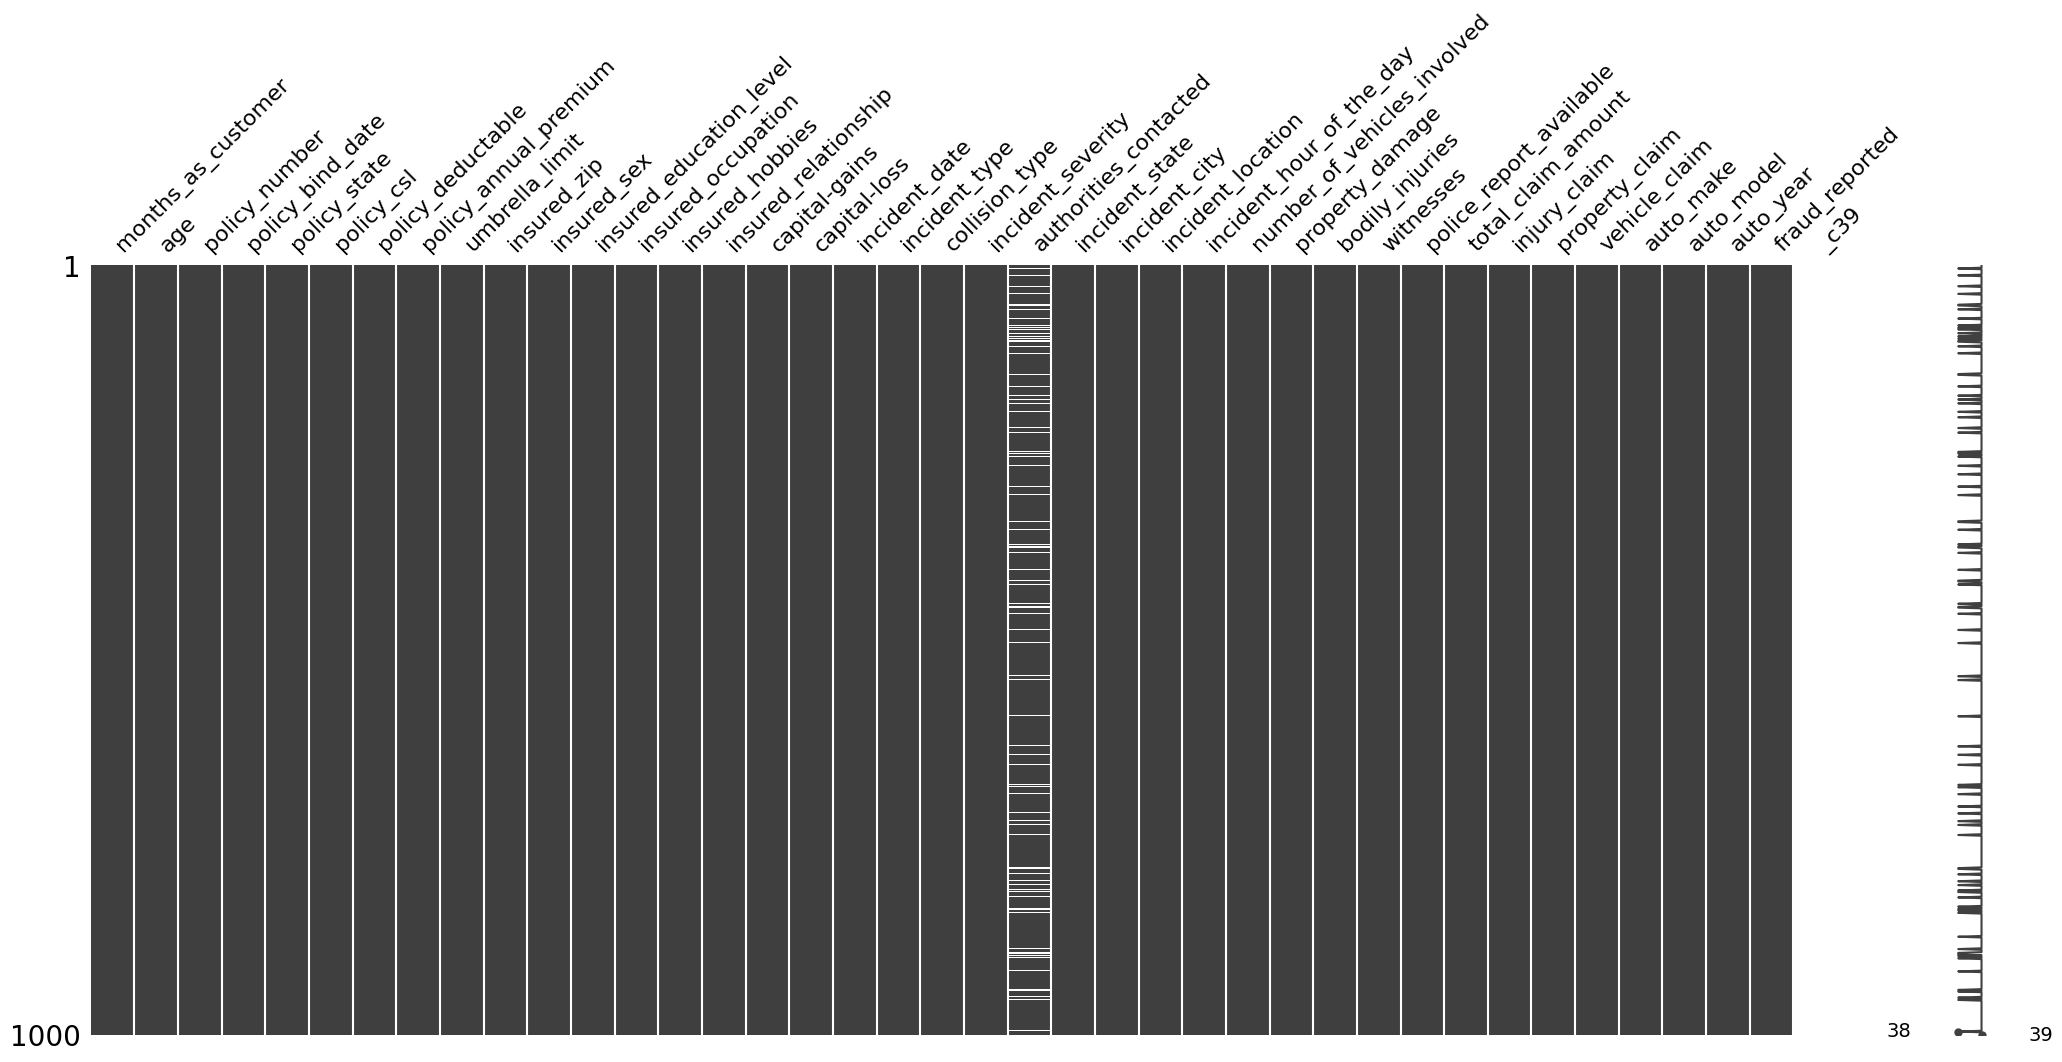

In [ ]:
msno.matrix(df)

In [ ]:
df_num=df.select_dtypes(include=['int64','float64'])
df_cat=df.select_dtypes(include=['object','category'])


In [ ]:
df_num=df_num.drop('_c39', axis=1)

In [ ]:
df_cat

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
0,2014-10-17,OH,250/500,MALE,MD,craft-repair,sleeping,husband,2015-01-25,Single Vehicle Collision,...,Major Damage,Police,SC,Columbus,9935 4th Drive,YES,YES,Saab,92x,Y
1,2006-06-27,IN,250/500,MALE,MD,machine-op-inspct,reading,other-relative,2015-01-21,Vehicle Theft,...,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,?,?,Mercedes,E400,Y
2,2000-09-06,OH,100/300,FEMALE,PhD,sales,board-games,own-child,2015-02-22,Multi-vehicle Collision,...,Minor Damage,Police,NY,Columbus,7121 Francis Lane,NO,NO,Dodge,RAM,N
3,1990-05-25,IL,250/500,FEMALE,PhD,armed-forces,board-games,unmarried,2015-01-10,Single Vehicle Collision,...,Major Damage,Police,OH,Arlington,6956 Maple Drive,?,NO,Chevrolet,Tahoe,Y
4,2014-06-06,IL,500/1000,MALE,Associate,sales,board-games,unmarried,2015-02-17,Vehicle Theft,...,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,NO,NO,Accura,RSX,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1991-07-16,OH,500/1000,FEMALE,Masters,craft-repair,paintball,unmarried,2015-02-22,Single Vehicle Collision,...,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,YES,?,Honda,Accord,N
996,2014-01-05,IL,100/300,FEMALE,PhD,prof-specialty,sleeping,wife,2015-01-24,Single Vehicle Collision,...,Major Damage,Fire,SC,Northbend,3092 Texas Drive,YES,?,Volkswagen,Passat,N
997,2003-02-17,OH,250/500,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,2015-01-23,Multi-vehicle Collision,...,Minor Damage,Police,NC,Arlington,7629 5th St,?,YES,Suburu,Impreza,N
998,2011-11-18,IL,500/1000,MALE,Associate,handlers-cleaners,base-jumping,wife,2015-02-26,Single Vehicle Collision,...,Major Damage,Other,NY,Arlington,6128 Elm Lane,?,YES,Audi,A5,N


In [ ]:
from sklearn.impute import SimpleImputer

imp =SimpleImputer(strategy='most_frequent')
df_cat[['authorities_contacted']]=imp.fit_transform(df_cat[['authorities_contacted']])
df_cat

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
0,2014-10-17,OH,250/500,MALE,MD,craft-repair,sleeping,husband,2015-01-25,Single Vehicle Collision,...,Major Damage,Police,SC,Columbus,9935 4th Drive,YES,YES,Saab,92x,Y
1,2006-06-27,IN,250/500,MALE,MD,machine-op-inspct,reading,other-relative,2015-01-21,Vehicle Theft,...,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,?,?,Mercedes,E400,Y
2,2000-09-06,OH,100/300,FEMALE,PhD,sales,board-games,own-child,2015-02-22,Multi-vehicle Collision,...,Minor Damage,Police,NY,Columbus,7121 Francis Lane,NO,NO,Dodge,RAM,N
3,1990-05-25,IL,250/500,FEMALE,PhD,armed-forces,board-games,unmarried,2015-01-10,Single Vehicle Collision,...,Major Damage,Police,OH,Arlington,6956 Maple Drive,?,NO,Chevrolet,Tahoe,Y
4,2014-06-06,IL,500/1000,MALE,Associate,sales,board-games,unmarried,2015-02-17,Vehicle Theft,...,Minor Damage,Police,NY,Arlington,3041 3rd Ave,NO,NO,Accura,RSX,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1991-07-16,OH,500/1000,FEMALE,Masters,craft-repair,paintball,unmarried,2015-02-22,Single Vehicle Collision,...,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,YES,?,Honda,Accord,N
996,2014-01-05,IL,100/300,FEMALE,PhD,prof-specialty,sleeping,wife,2015-01-24,Single Vehicle Collision,...,Major Damage,Fire,SC,Northbend,3092 Texas Drive,YES,?,Volkswagen,Passat,N
997,2003-02-17,OH,250/500,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,2015-01-23,Multi-vehicle Collision,...,Minor Damage,Police,NC,Arlington,7629 5th St,?,YES,Suburu,Impreza,N
998,2011-11-18,IL,500/1000,MALE,Associate,handlers-cleaners,base-jumping,wife,2015-02-26,Single Vehicle Collision,...,Major Damage,Other,NY,Arlington,6128 Elm Lane,?,YES,Audi,A5,N


In [ ]:
df_cat.isnull().sum()

,0
policy_bind_date,0
policy_state,0
policy_csl,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_hobbies,0
insured_relationship,0
incident_date,0
incident_type,0


<Axes: >

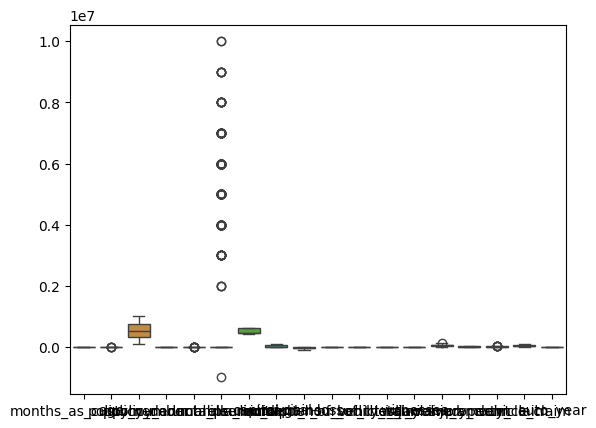

In [ ]:
sns.boxplot(df_num)

In [ ]:
from sklearn.ensemble import IsolationForest

iso=IsolationForest(contamination=0.1)
df_num['outlier']= iso.fit_predict(df_num)
df_num[df_num['outlier']==-1]

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,outlier
2,134,29,687698,2000,1413.14,5000000,430632,35100,0,7,3,2,3,34650,7700,3850,23100,2007,-1
4,228,44,367455,1000,1583.91,6000000,610706,66000,-46000,20,1,0,1,6500,1300,650,4550,2009,-1
11,447,61,214618,2000,1137.16,0,615561,0,-51000,21,3,1,2,114920,17680,17680,79560,2006,-1
15,473,58,892874,2000,1131.40,0,458733,55700,0,12,4,0,0,63120,10520,10520,42080,1999,-1
20,460,62,183430,1000,1187.96,4000000,618845,0,0,20,3,1,0,47160,0,5240,41920,2011,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,31,32,231548,2000,1263.48,4000000,442948,46800,-87300,10,1,2,0,63600,5300,10600,47700,1997,-1
949,407,55,193213,1000,1250.08,5000000,474598,0,-57700,0,3,2,3,68160,11360,11360,45440,2010,-1
969,398,55,844062,500,862.19,0,606858,69400,0,7,1,2,3,6600,600,1200,4800,2012,-1
996,285,41,186934,1000,1436.79,0,608177,70900,0,23,1,2,3,108480,18080,18080,72320,2015,-1


In [ ]:
df_num.skew().sort_values(ascending=False)

,0
umbrella_limit,1.806712
insured_zip,0.816554
number_of_vehicles_involved,0.502664
age,0.478988
capital-gains,0.478850
policy_deductable,0.477887
property_claim,0.378169
months_as_customer,0.362177
injury_claim,0.264811
policy_number,0.038991


In [ ]:
df_num['capital-loss_shifted'] = df_num['capital-loss'] - df_num['capital-loss'].min() + 1
df_num['umbrella_limit_shifted'] = df_num['umbrella_limit'] - df_num['umbrella_limit'].min() + 1
col=['capital-loss_shifted','umbrella_limit_shifted']
np.log(df_num[col])

,capital-loss_shifted,umbrella_limit_shifted
0,11.618195,13.815512
1,11.618195,15.607270
2,11.618195,15.607270
3,10.793455,15.761421
4,11.083695,15.761421
...,...,...
995,11.618195,13.815512
996,11.618195,13.815512
997,11.618195,15.201805
998,11.618195,15.607270


In [ ]:
cols=['incident_hour_of_the_day','auto_year','total_claim_amount','vehicle_claim']
np.log(df_num[cols])

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,incident_hour_of_the_day,auto_year,total_claim_amount,vehicle_claim
0,1.609438,7.602900,11.178990,10.860536
1,2.079442,7.604396,8.531096,8.163371
2,1.945910,7.604396,10.453053,10.047588
3,1.609438,7.607878,11.057219,10.834076
4,2.995732,7.605392,8.779557,8.422883
...,...,...,...,...
995,2.995732,7.603898,11.375960,11.019285
996,3.135494,7.608374,11.594321,11.188856
997,1.386294,7.598900,11.119883,10.868568
998,0.693147,7.599902,10.757477,10.506163


In [ ]:
from sklearn.preprocessing import OneHotEncoder

one=OneHotEncoder(sparse_output=False)
encoded=one.fit_transform(df_cat)
df_cat = pd.DataFrame(encoded,columns=one.get_feature_names_out(df_cat.columns))
df_cat

,policy_bind_date_1990-01-08,policy_bind_date_1990-01-27,policy_bind_date_1990-02-01,policy_bind_date_1990-02-03,policy_bind_date_1990-02-08,policy_bind_date_1990-02-14,policy_bind_date_1990-02-15,policy_bind_date_1990-02-18,policy_bind_date_1990-02-23,policy_bind_date_1990-03-14,...,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6,fraud_reported_N,fraud_reported_Y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_final = pd.concat([df_num, df_cat], axis=1)

In [ ]:
df_final

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,...,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6,fraud_reported_N,fraud_reported_Y
0,328,48,521585,1000,1406.91,0,466132,53300,0,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,228,42,342868,2000,1197.22,5000000,468176,0,0,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,134,29,687698,2000,1413.14,5000000,430632,35100,0,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,256,41,227811,2000,1415.74,6000000,608117,48900,-62400,5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,228,44,367455,1000,1583.91,6000000,610706,66000,-46000,20,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1000,1310.80,0,431289,0,0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
996,285,41,186934,1000,1436.79,0,608177,70900,0,23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,130,34,918516,500,1383.49,3000000,442797,35100,0,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
998,458,62,533940,2000,1356.92,5000000,441714,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X = df_final.drop(['fraud_reported_Y', 'fraud_reported_N'], axis=1)
y = df_final['fraud_reported_Y']

In [ ]:
import numpy as np

df_final = df_final.replace([np.inf, -np.inf], np.nan)
df_final = df_final.fillna(df_final.median(numeric_only=True))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=40)

In [ ]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(X_train.median(numeric_only=True))

In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3,random_state=40)


In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=40)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)


[0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 1.
 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 0. 0. 0. 0.]


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.965


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

[[137   3]
 [  4  56]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.98      0.98       140
         1.0       0.95      0.93      0.94        60

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



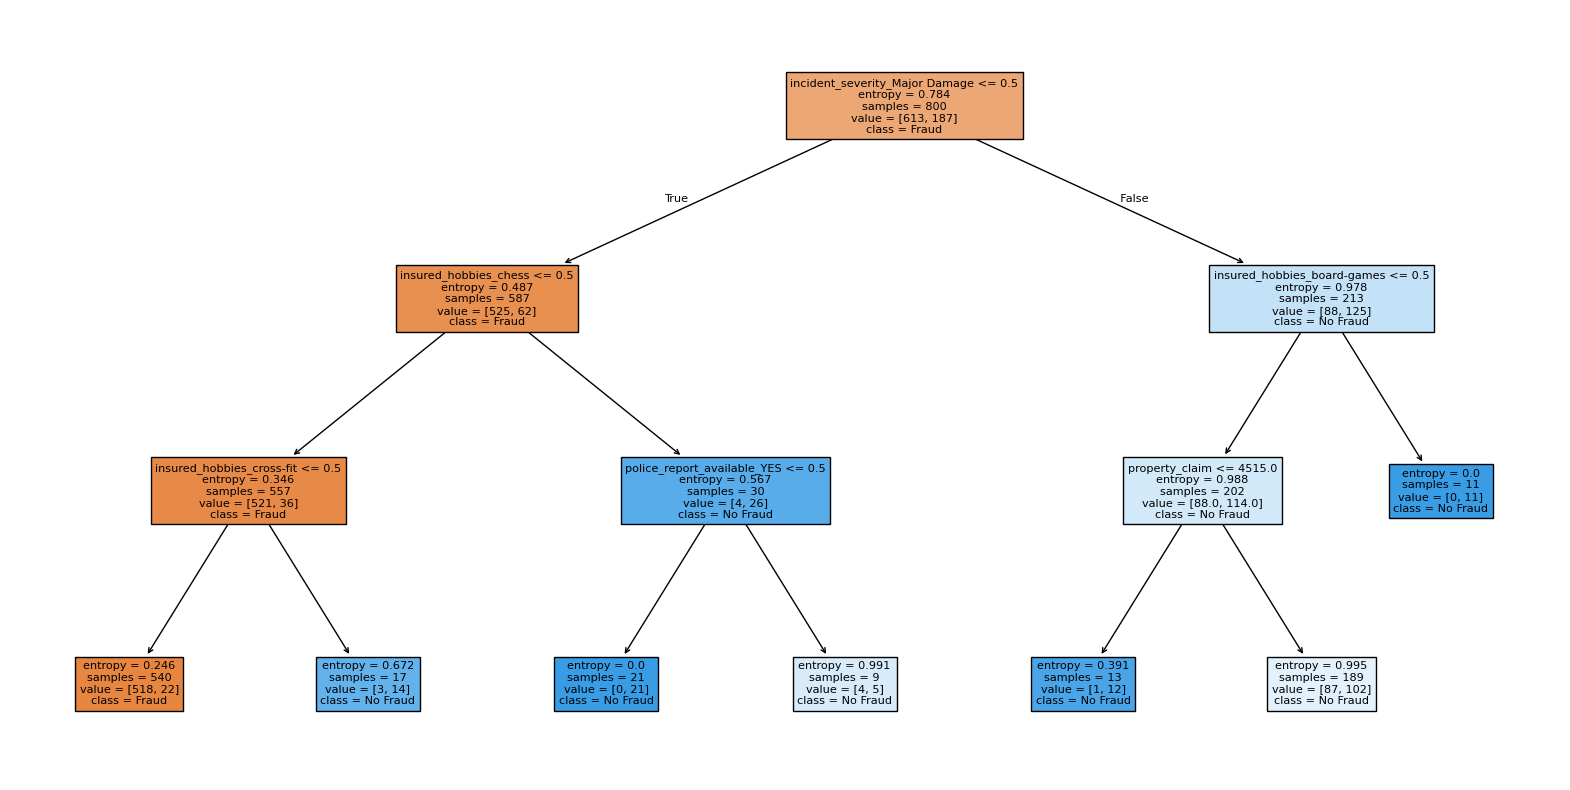

In [ ]:
from sklearn.tree import plot_tree

plt.show()
plt.figure(figsize=(20,10))
plot_tree(clf,feature_names=X.columns,class_names=['Fraud', 'No Fraud'],filled=True)
plt.show()